In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('place.csv')

In [3]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


<Axes: xlabel='placement_exam_marks', ylabel='Count'>

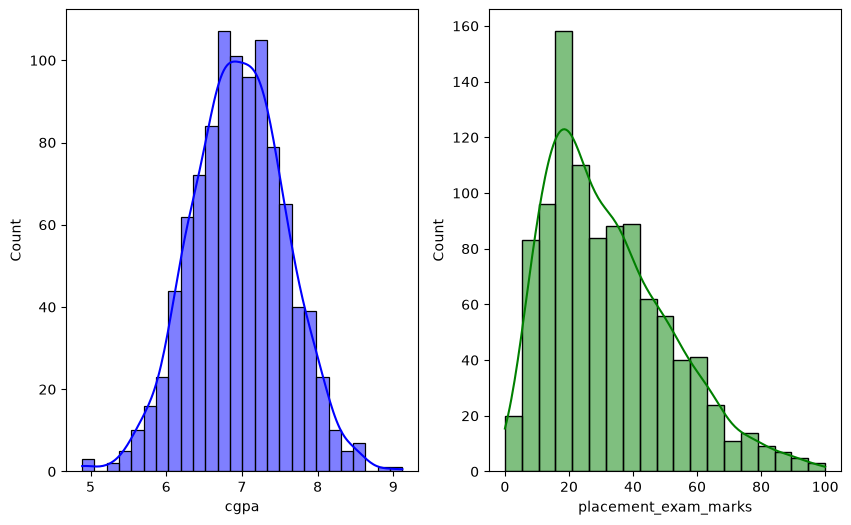

In [4]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sns.histplot(df['cgpa'], kde=True, color='blue')

plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'], kde=True, color='green')


In [5]:
print('mean of cgpa:', df['cgpa'].mean())
print('std of cgpa:', df['cgpa'].std())
print('min of cgpa:', df['cgpa'].min())
print('max of cgpa:', df['cgpa'].max())

mean of cgpa: 6.96124
std of cgpa: 0.6158978751323896
min of cgpa: 4.89
max of cgpa: 9.12


In [6]:
# to find the boundaries values of the cgpa we can use the formulae

print('lower boundary of cgpa:', df['cgpa'].mean() - 3*df['cgpa'].std())
print('upper boundary of cgpa:', df['cgpa'].mean() + 3*df['cgpa'].std())

lower boundary of cgpa: 5.113546374602832
upper boundary of cgpa: 8.808933625397168


In [7]:
df[(df['cgpa'] > 8.80 ) | (df['cgpa'] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [8]:
df.shape

(1000, 3)

# Trimming

In [9]:
new_df = df[(df['cgpa'] < 8.80 ) & (df['cgpa'] > 5.11)]
new_df.shape

(995, 3)

### Z - score method

In [10]:
df['z_scored'] = (df['cgpa'] - df['cgpa'].mean()) / df['cgpa'].std()

In [11]:
df.head()

,cgpa,placement_exam_marks,placed,z_scored
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [12]:
df[(df['z_scored'] > 3) | (df['z_scored'] < -3)]

,cgpa,placement_exam_marks,placed,z_scored
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [13]:
new_df2 = df[(df['z_scored'] < 3) & (df['z_scored'] > -3)]

In [14]:
new_df.shape

(995, 3)

In [15]:
upper_bound = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_bound = df['cgpa'].mean() - 3*df['cgpa'].std()

In [16]:
print(upper_bound)

8.808933625397168


# Capping

In [18]:
upper = df['cgpa'].mean() + 3*df['cgpa'].std()
lower = df['cgpa'].mean() - 3*df['cgpa'].std()

In [19]:
df['cgpa'] = np.where(df['cgpa'] > upper, upper, np.where(df['cgpa'] < lower, lower, df['cgpa']))

In [20]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64